<a href="https://colab.research.google.com/github/sudarshan0419/ds_cheatsheet/blob/master/Group_Project_Part_2_Deliverable_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries and Recommendation System Tools**

Data handling, numerical operations, data visualization, data recommender modelling and evaluation were made by importing the required libraries and tools. Preparation of tools for loading of data sets, training of models, tuning of parameters and measuring model performance.

In [ ]:
# Importing data handling tools
import pandas as pd
import numpy as np

# Importing visualization tools
import matplotlib.pyplot as plt

# Importing dataset access tools
from ucimlrepo import fetch_ucirepo

# Importing recommendation system tools
from surprise import (
    Dataset,
    Reader,
    SVD,
    accuracy
)

# Importing model training and tuning tools
from surprise.model_selection import (
    train_test_split,
    GridSearchCV
)

# Importing evaluation measurement tools
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

**Loading and Combining the Heart Disease Dataset**

UCI Heart Disease dataset was loaded and the feature and target information was extracted. The features and target were merged into a single table and the initial records were presented.

In [ ]:
# Loading the UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Extracting feature information
X = heart_disease.data.features

# Extracting target information
y = heart_disease.data.targets

# Combining features and target
heart_data = pd.concat([X, y], axis=1)

# Displaying the first records
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


**Checking Dataset Shape and Information**

The dataset shape was checked to identify the number of rows and columns. The information in the data set was presented for previewing the types of columns and the available entries.

In [ ]:
# Displaying dataset shape
print("Dataset Shape:")
print(heart_data.shape)

# Displaying dataset information
print("\nDataset Information:")
heart_data.info()

Dataset Shape:
(303, 14)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


**Handling and Checking Missing Values**

Missing values in the ca and thal columns were replaced using the median values of the columns. All data that were missing were reviewed to verify that the data was complete.

In [ ]:
# Filling missing values in ca
heart_data['ca'] = heart_data['ca'].fillna(heart_data['ca'].median())

# Filling missing values in thal
heart_data['thal'] = heart_data['thal'].fillna(heart_data['thal'].median())

# Checking remaining missing values
print(heart_data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


**Creating Patient IDs and Preparing Rating Data**

Patients IDs were generated and the data was transformed into a user item rating format for the recommendation modeling process. The data that was converted, including the missing values, were deleted and the converted data was presented for examination.

In [ ]:
# Creating patient identifiers
heart_data['patient_id'] = heart_data.index

# Converting data into user item rating format
svd_data = heart_data.melt(
    id_vars=['patient_id'],
    var_name='item_id',
    value_name='rating'
)

# Removing missing values
svd_data = svd_data.dropna()

# Displaying the converted data
svd_data.head()

,patient_id,item_id,rating
0,0,age,63.0
1,1,age,67.0
2,2,age,67.0
3,3,age,37.0
4,4,age,41.0


**Preparing the Surprise Dataset**

The range of ratings was determined by using the lowest and highest values found. The patient, item, and rating values were transformed to a Surprise dataset to be used for recommendation modeling.

In [ ]:
# Finding the minimum rating
minimum_rating = svd_data['rating'].min()

# Finding the maximum rating
maximum_rating = svd_data['rating'].max()

# Defining the rating range
reader = Reader(rating_scale=(minimum_rating, maximum_rating))

# Creating the Surprise dataset
data_surprise = Dataset.load_from_df(
    svd_data[['patient_id', 'item_id', 'rating']],
    reader
)

# Confirming dataset creation
print("Surprise dataset created successfully")

Surprise dataset created successfully


**Splitting the Dataset into Training and Testing Sets**

The Surprise dataset was split into a 75% training and 25% testing set. The numbers of training and testing ratings were displayed for verification.

In [ ]:
# Splitting the dataset into training and testing sets
trainset, testset = train_test_split(data_surprise,test_size=0.25,random_state=42)

# Displaying the number of training ratings
print("Training ratings:", trainset.n_ratings)

# Displaying the number of testing ratings
print("Testing ratings:", len(testset))

Training ratings: 3181
Testing ratings: 1061


**Training and Evaluating the Initial SVD Model**

The training ratings were used to train an initial SVD model and predictions were made for the testing ratings. The initial model performance was measured by calculating the RMSE and MAE values.

In [ ]:
# Creating the initial SVD model
initial_svd = SVD(random_state=42)

# Training the model
initial_svd.fit(trainset)

# Generating predictions
initial_predictions = initial_svd.test(testset)

# Calculating RMSE
initial_rmse = accuracy.rmse(initial_predictions, verbose=False)

# Calculating MAE
initial_mae = accuracy.mae(initial_predictions, verbose=False)

# Displaying initial model results
print("Initial SVD Model")
print("RMSE:", initial_rmse)
print("MAE:", initial_mae)

Initial SVD Model
RMSE: 529.859263097207
MAE: 524.6649387370405


**Tuning the SVD Model Parameters**

Various sets of SVD parameters were generated and tested to find the settings that gave the best performance in terms of RMSE and MAE. Three fold cross validation was used to compare the parameter combinations and select the best settings.

In [ ]:
# Defining parameter combinations
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [20, 40],
    'lr_all': [0.002, 0.005]
}

# Creating the grid search
grid_search = GridSearchCV(
    SVD,
    param_grid,
    measures=['rmse', 'mae'],
    cv=3
)

# Running parameter tuning
grid_search.fit(data_surprise)

# Displaying the best RMSE
print("Best RMSE:")
print(grid_search.best_score['rmse'])

# Displaying the best parameters
print("\nBest Parameters:")
print(grid_search.best_params['rmse'])

Best RMSE:
18.891025610480273

Best Parameters:
{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.002}


**Creating and Training the Optimized SVD Model**

The best parameters of SVD were optimized from the tuning result and applied to build a model optimized. The optimal model was trained using the training ratings and was ready for final evaluation.

In [ ]:
# Extracting the best parameters
best_params = grid_search.best_params['rmse']

# Creating the optimized SVD model
final_svd = SVD(
    n_factors=best_params['n_factors'],
    n_epochs=best_params['n_epochs'],
    lr_all=best_params['lr_all'],
    random_state=42
)

# Training the final model
final_svd.fit(trainset)

# Confirming model training
print("Optimized SVD model trained successfully")

Optimized SVD model trained successfully


**Evaluating the Final Optimized SVD Model**

The optimized SVD model was used to make predictions and they were compared with the testing ratings. The final model performance was measured using the value of RMSE and MAE.

In [ ]:
# Generating predictions from the final model
final_predictions = final_svd.test(testset)

# Calculating RMSE
final_rmse = accuracy.rmse(final_predictions, verbose=False)

# Calculating MAE
final_mae = accuracy.mae(final_predictions, verbose=False)

# Displaying final model results
print("Final Optimized Model Results")
print("RMSE:", final_rmse)
print("MAE:", final_mae)

Final Optimized Model Results
RMSE: 17.745881988999095
MAE: 6.475516483376439


**Comparing Initial and Optimized SVD Models**

The RMSE and MAE results from the initial and optimized SVD models were organized into a comparison table. The table was displayed to compare the performance of both models.

In [ ]:
# Creating model comparison table
comparison = pd.DataFrame({
    "Model": ["Initial SVD", "Optimized SVD"],
    "RMSE": [initial_rmse, final_rmse],
    "MAE": [initial_mae, final_mae]
})

# Displaying model comparison
comparison

,Model,RMSE,MAE
0,Initial SVD,529.859263,524.664939
1,Optimized SVD,17.745882,6.475516


The optimized SVD model reduced RMSE and MAE values significantly from the initial SVD model, hence the model was found to be better. The RMSE value went from 529.86 to 17.75, showing that the tuned model's predictions were much closer to the actual ratings. The average prediction error was significantly lowered from 524.66 to 6.48 after hyperparameter tuning. Overall, the optimized model proves to be more accurate in predicting and more to capture the pattern in the transformed recommendation data set.

**Creating Prediction Results and Calculating Errors**

The final predictions were arranged by patient ID, features, actual ratings and predicted ratings for review. The first ten are shown and prediction errors were computed as the difference between predicted ratings and actual ratings.

In [ ]:
# Converting predictions into a table
prediction_results = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in final_predictions],
    columns=[
        "Patient_ID",
        "Feature",
        "Actual_Rating",
        "Predicted_Rating"
    ]
)

# Calculating prediction errors
prediction_results['Error'] = (
    prediction_results['Predicted_Rating'] -
    prediction_results['Actual_Rating']
)

# Displaying the first ten prediction results
prediction_results.head(10)

,Patient_ID,Feature,Actual_Rating,Predicted_Rating,Error
0,150,num,0.0,0.802610,0.802610
1,203,thalach,133.0,145.383741,12.383741
2,285,exang,0.0,3.135362,3.135362
3,125,num,0.0,0.000000,0.000000
4,205,thal,7.0,6.233765,-0.766235
5,171,restecg,2.0,0.181027,-1.818973
6,98,ca,1.0,0.000000,-1.000000
7,241,thalach,163.0,153.028353,-9.971647
8,157,restecg,2.0,1.375469,-0.624531
9,246,fbs,0.0,0.000000,0.000000


**Calculating Additional Evaluation Metrics**

The actual values were separated from the predicted values and the values of MSE and R2 Score were calculated. Evaluation table was created to present the final RMSE, MAE, MSE and R2 Score values.

In [ ]:
# Separating actual ratings
actual = prediction_results['Actual_Rating']

# Separating predicted ratings
predicted = prediction_results['Predicted_Rating']

# Calculating mean squared error
mse = mean_squared_error(actual, predicted)

# Calculating R2 score
r2 = r2_score(actual, predicted)

# Creating evaluation table
evaluation_table = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "MSE", "R2 Score"],
    "Value": [final_rmse, final_mae, mse, r2]
})

# Displaying evaluation results
evaluation_table

,Metric,Value
0,RMSE,17.745882
1,MAE,6.475516
2,MSE,314.916328
3,R2 Score,0.942508


The final optimized SVD model achieved an RMSE of 17.75 and an MAE of 6.48, indicating that the prediction errors were relatively low compared with the original model. The MSE value was 314.92, indicating that the average squared error between the forecasted and actual ratings was low, which suggests that the model provided a good predictive performance. The R² score of 0.9425 indicates that the model explains approximately 94.25% of the variation in the predicted ratings. The overall evaluation metrics show that the optimized model successfully learnt the patterns from the transformed data set and achieved better prediction accuracy.

**Visualize Actual and Predicted Ratings**

A scatter chart was used to illustrate the relationship between the actual ratings and the predicted ratings. Axis labels and a title were added to make the prediction results easier to understand.

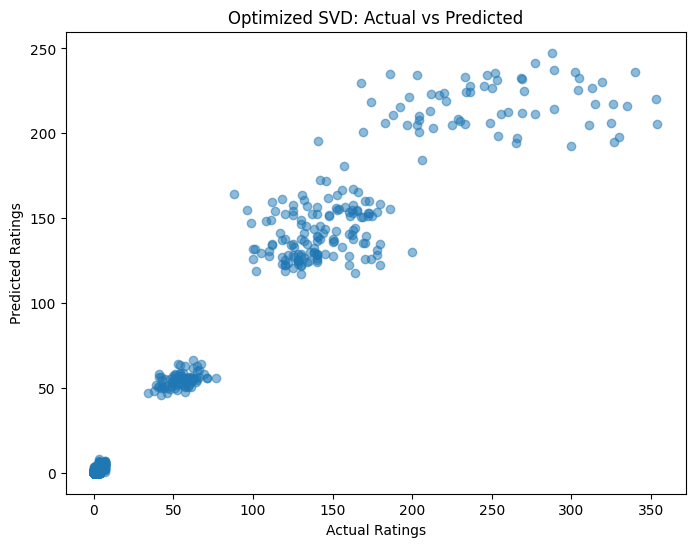

In [ ]:
# Creating the scatter plot
plt.figure(figsize=(8, 6))

# Plotting actual and predicted ratings
plt.scatter(actual, predicted, alpha=0.5)

# Adding axis labels
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")

# Adding the plot title
plt.title("Optimized SVD: Actual vs Predicted")

# Displaying the plot
plt.show()

The scatter plot shows a positive relationship between actual and predicted ratings, indicating that the optimized SVD model captures general patterns in the dataset. Most predictions follow the increasing trend of actual values, showing that the model can learn relationships between patient features. There are some points that lie outside the predicted trend line, which shows that there are some errors in predictions for some values of the feature. Other errors could be due to the limited size of the data for the healthcare attributes and the transformation of those attributes into recommendation-based ratings.

**Visualizing the Prediction Error Distribution**

Prediction errors were displayed in a histogram to examine the distribution of differences between predicted and actual ratings. Axis labels and a title were added to make the error distribution easier to interpret.

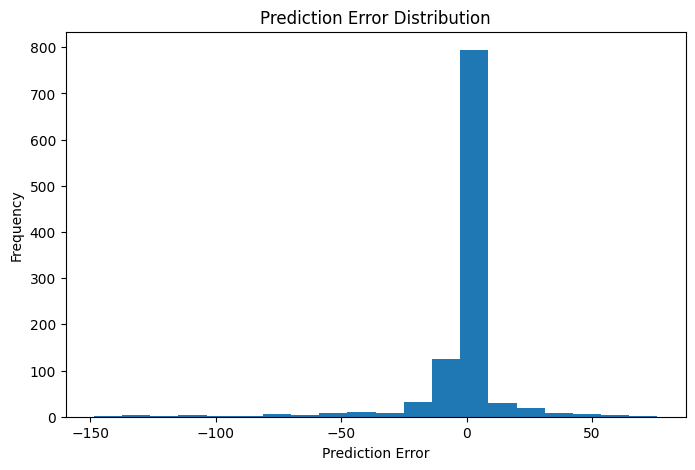

In [ ]:
# Creating the prediction error histogram
plt.figure(figsize=(8, 5))

# Plotting the prediction errors
plt.hist(prediction_results['Error'], bins=20)

# Adding axis labels
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

# Adding the plot title
plt.title("Prediction Error Distribution")

# Displaying the plot
plt.show()

The distribution of the errors is centered around zero, suggesting that there is not a lot of variation from the actual ratings. The model exhibits small prediction errors most of the time, implying that the model is reasonably accurate in predicting. A few larger positive and negative errors indicate cases where the model overestimated or underestimated certain ratings. The extreme errors can be due to difference in patients' characteristics and the small sample size.